In [ ]:
# ══ SETUP + CARGA ════════════════════════════════════════════════════════
!pip install PyWavelets -q

from google.colab import drive
drive.mount('/content/drive')

import os, glob
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy import stats
import warnings; warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

BASE = '/content/drive/MyDrive/psib_parte2'
FS = 500
LABELS = ['R_SUB','R_DG','R_CA1','R_CA3','R_AMD','R_ANT',
          'L_SUB','L_DG','L_CA1','L_CA3','L_AMD','L_ANT']

# ── etiquetas: el producto del detector CWT ─────────────────────────────
ETIQ = np.load(f'{BASE}/etiquetas.npy', allow_pickle=True).item()

# ── señales ─────────────────────────────────────────────────────────────
SIG = {}
for carpeta in ['senales', 'senales_non']:
    for f in sorted(glob.glob(f'{BASE}/{carpeta}/*.npz')):
        fid = os.path.basename(f)[:-4]
        if fid in ETIQ:                      # solo los que tienen etiqueta
            SIG[fid] = np.load(f)['sig']

print(f'{len(SIG)} fragmentos cargados\n')
print(f'{"fragmento":<24s}{"rata":>7s}{"tipo":>10s}{"onset":>9s}'
      f'{"interictal":>12s}{"ictal":>9s}')
print('-'*72)
for fid in sorted(ETIQ, key=lambda x: (ETIQ[x]['rata'], x)):
    e = ETIQ[fid]
    tipo = 'ictal' if e['ictal'] else 'non'
    ons  = f'{e["onset"]:.1f}s' if e['onset'] else '—'
    ii   = e['interictal'][1] - e['interictal'][0]
    ic   = e['ictal'][1] - e['ictal'][0] if e['ictal'] else 0
    ok   = '' if fid in SIG else '   ✗ FALTA LA SEÑAL'
    print(f'{fid:<24s}{e["rata"]:>7s}{tipo:>10s}{ons:>9s}{ii:>10.0f}s{ic:>8.0f}s{ok}')

ratas = sorted({e['rata'] for e in ETIQ.values()})
print(f'\n  {len(ratas)} ratas: {", ".join(ratas)}')
print(f'  {sum(1 for e in ETIQ.values() if e["ictal"])} fragmentos con tramo ictal')
print(f'  {sum(1 for e in ETIQ.values() if not e["ictal"])} solo interictal (los non)')

Mounted at /content/drive
23 fragmentos cargados

fragmento                  rata      tipo    onset  interictal    ictal
------------------------------------------------------------------------
B6_2023_7_23-non1         RatB6       non        —       600s       0s
B6_2023_7_23-non2         RatB6       non        —       600s       0s
B6_2023_7_24-ictal1       RatB6     ictal   317.6s       288s      20s
B6_2023_7_25-ictal1       RatB6     ictal   298.2s       268s      20s
C16_2023_10_30-ictal1    RatC16     ictal   283.1s       253s      20s
C16_2023_10_31-ictal1    RatC16     ictal   272.7s       243s      20s
C16_2023_11_1-non1       RatC16       non        —       600s       0s
C16_2023_11_1-non2       RatC16       non        —       600s       0s
C3_2023_10_23-ictal1      RatC3     ictal   325.9s       296s      20s
C3_2023_10_24-ictal1      RatC3     ictal   349.1s       319s      20s
C3_2023_10_26-non1        RatC3       non        —       600s       0s
C3_2023_10_26-non2      

ML necesita mas muetras de las qu eetsamos usando --> 1 registro de 600s  →  ~600 ventanas  →  ~600 filas de la tabla
23 registros        →  ~10.000 filas

In [ ]:
# ══ VENTANEO — acá entran las etiquetas del detector ═════════════════════
# Cada ventana hereda su clase según en qué tramo cae. La zona ambigua
# alrededor del onset ya está excluida en etiquetas.npy.
WIN_S, STEP_S = 2.0, 1.0

VENTANAS = []          # (fid, rata, t_inicio, clase)
for fid, e in ETIQ.items():
    if fid not in SIG: continue
    T = SIG[fid].shape[0]/FS
    t = 0.0
    while t + WIN_S <= T:
        t_fin = t + WIN_S
        clase = None
        if e['interictal'][0] <= t and t_fin <= e['interictal'][1]:
            clase = 0
        elif e['ictal'] and e['ictal'][0] <= t and t_fin <= e['ictal'][1]:
            clase = 1
        if clase is not None:
            VENTANAS.append((fid, e['rata'], t, clase))
        t += STEP_S

import collections
print(f'{len(VENTANAS)} ventanas de {WIN_S}s (paso {STEP_S}s)\n')
print(f'{"rata":<9s}{"interictal":>12s}{"ictal":>9s}{"ratio":>9s}')
print('-'*40)
for r in ratas:
    v = [x for x in VENTANAS if x[1]==r]
    n0 = sum(1 for x in v if x[3]==0); n1 = sum(1 for x in v if x[3]==1)
    print(f'{r:<9s}{n0:>12d}{n1:>9d}{(n0/n1 if n1 else 0):>8.0f}:1')
n0 = sum(1 for x in VENTANAS if x[3]==0)
n1 = sum(1 for x in VENTANAS if x[3]==1)
print('-'*40)
print(f'{"TOTAL":<9s}{n0:>12d}{n1:>9d}{n0/n1:>8.0f}:1')

print(f"""
⚠ DOS PROBLEMAS QUE HAY QUE DECLARAR

1. DESBALANCE {n0/n1:.0f}:1 → un modelo que diga "no hay crisis" siempre
   acierta el {100*n0/(n0+n1):.1f}%. Por eso NO se reporta accuracy: van
   sensibilidad, especificidad y AUC. Se usa class_weight='balanced'.

2. VENTANAS SOLAPADAS: con paso {STEP_S}s en ventanas de {WIN_S}s, cada una
   comparte la mitad de sus datos con la siguiente. Las {n1} ictales NO son
   {n1} muestras independientes — son ~{int(n1*STEP_S/WIN_S)} de información real.
   No infla el resultado (LORO separa por rata), pero el N es engañoso.
""")

10348 ventanas de 2.0s (paso 1.0s)

rata       interictal    ictal    ratio
----------------------------------------
RatB6            1751       36      49:1
RatC16           1691       36      47:1
RatC3            1810       36      50:1
RatD17           1714       36      48:1
RatE2            1744       36      48:1
RatR2            1440       18      80:1
----------------------------------------
TOTAL           10150      198      51:1

⚠ DOS PROBLEMAS QUE HAY QUE DECLARAR

1. DESBALANCE 51:1 → un modelo que diga "no hay crisis" siempre
   acierta el 98.1%. Por eso NO se reporta accuracy: van
   sensibilidad, especificidad y AUC. Se usa class_weight='balanced'.

2. VENTANAS SOLAPADAS: con paso 1.0s en ventanas de 2.0s, cada una
   comparte la mitad de sus datos con la siguiente. Las 198 ictales NO son
   198 muestras independientes — son ~99 de información real.
   No infla el resultado (LORO separa por rata), pero el N es engañoso.



Por qué WPD y no DWT
La teoría lo dice: "la WPD es una generalización de la DWT, útil cuando querés un análisis más flexible o con mayor resolución".
La diferencia concreta: la DWT solo sigue descomponiendo la parte de baja frecuencia, así que te da bandas diádicas — 125-250, 62-125, 31-62… Las altas quedan gruesas. La WPD descompone las dos ramas, y a nivel 6 te da 64 bandas uniformes de ~3.9 Hz cada una.
Eso importa acá porque los SOPs del paper viven en bandas angostas (theta/alpha 6-11 Hz, espigas rítmicas 4-18). Con DWT no las distinguís; con WPD sí.

Si le doy potencia absoluta, el modelo aprende a reconocer la rata, no la crisis. Y con LORO, cuando le toque una rata que nunca vio, se cae.
Por eso las features van normalizadas dentro de cada ventana: energía relativa por banda (qué fracción del total hay en cada una) y entropía. Eso describe la forma del espectro, que es lo que cambia en una crisis, y no depende de la escala del electrodo.
db4 como wavelet madre

Por canal, sobre cada ventana:

WPD nivel 6 con db4 → parte 0–250 Hz en 64 bandas de 3.9 Hz.
Energía de cada nodo, agrupada en las 5 bandas clásicas.
Normaliza: divide por la energía total → energía relativa, la fracción que hay en cada banda.
Entropía de Shannon sobre esa distribución → un número que dice si la energía está concentrada en pocas bandas (crisis, oscilación rítmica) o repartida (basal, ruido).
Eso da 6 features por canal × 12 canales = 72 columnas.
Por qué relativa y no absoluta: B6 tiene ±5000 µV y C16 ±300. Con potencia absoluta, el modelo aprende a reconocer la rata y LORO se cae en la que nunca vio. La energía relativa describe la forma del espectro, que es lo que cambia en una crisis, y no depende de la escala del electrodo.

-  pywt devuelve los nodos en orden natural, que no es orden de frecuencia — es código Gray. Hay que pedir 'freq'. Con 'natural', tus bandas son frecuencias mezcladas al azar y el código corre igual.

In [ ]:
# ══ FEATURES CON WPD ═════════════════════════════════════════════════════
WAVELET_F, NIVEL = 'db4', 6
N_NODOS = 2**NIVEL                    # 64 nodos de 250/64 = 3.9 Hz c/u
BW = (FS/2) / N_NODOS

BANDAS_F = {'delta': (1,4), 'theta_alpha': (4,12), 'beta': (13,30),
            'gamma': (30,80), 'alta': (80,200)}

# nodo i cubre [i*BW, (i+1)*BW]  →  qué nodos caen en cada banda
NODOS = {}
for nom, (f0,f1) in BANDAS_F.items():
    NODOS[nom] = [i for i in range(N_NODOS)
                  if (i*BW < f1) and ((i+1)*BW > f0)]
print(f'WPD {WAVELET_F} nivel {NIVEL} → {N_NODOS} nodos de {BW:.1f} Hz\n')
for nom,(f0,f1) in BANDAS_F.items():
    print(f'  {nom:<12s} {f0:>3d}-{f1:<3d} Hz → {len(NODOS[nom]):>2d} nodos')

def features_canal(x):
    """6 features de una ventana de 1 canal: 5 energías relativas + entropía."""
    wp = pywt.WaveletPacket(x, WAVELET_F, maxlevel=NIVEL)
    # 'freq' y NO 'natural': pywt devuelve los nodos en código Gray
    nodos = wp.get_level(NIVEL, 'freq')
    E = np.array([np.sum(n.data**2) for n in nodos])
    Eb = np.array([E[NODOS[b]].sum() for b in BANDAS_F])
    tot = Eb.sum() + 1e-12
    rel = Eb / tot                              # energía RELATIVA
    ent = -np.sum(rel * np.log2(rel + 1e-12))   # entropía de Shannon
    return np.r_[rel, ent]

NOMBRES = [f'{b}_{ch}' for ch in LABELS for b in list(BANDAS_F)+['entropia']]

# ── construir la tabla ──────────────────────────────────────────────────
print(f'\nCalculando {len(VENTANAS)} ventanas × 12 canales...')
X, y, grupo, origen = [], [], [], []
for k, (fid, rata, t0, clase) in enumerate(VENTANAS):
    if k % 2000 == 0: print(f'  {k}/{len(VENTANAS)}')
    i0 = int(t0*FS); i1 = i0 + int(WIN_S*FS)
    seg = SIG[fid][i0:i1, :]
    X.append(np.concatenate([features_canal(seg[:,c]) for c in range(12)]))
    y.append(clase); grupo.append(rata); origen.append(fid)

X = np.array(X); y = np.array(y)
grupo = np.array(grupo); origen = np.array(origen)
print(f'\n  X: {X.shape}  ({X.shape[1]} features)')
print(f'  y: {np.sum(y==0)} interictal · {np.sum(y==1)} ictal')
print(f'  NaN: {np.isnan(X).sum()}  |  Inf: {np.isinf(X).sum()}')

np.savez_compressed(f'{BASE}/features_wpd.npz', X=X, y=y, grupo=grupo,
                    origen=origen, nombres=NOMBRES)
print(f'  ✓ guardado en {BASE}/features_wpd.npz')

# ── chequeo: ¿el modelo puede reconocer la RATA en vez de la crisis? ─────
print('\n' + '='*62)
print('CHEQUEO — energía relativa media por rata (solo interictal)')
print('='*62)
print(f'{"rata":<9s}' + ''.join(f'{b:>13s}' for b in BANDAS_F))
print('-'*74)
i_ent = NOMBRES.index('entropia_R_AMD')
i_b   = [NOMBRES.index(f'{b}_R_AMD') for b in BANDAS_F]
for r in ratas:
    m = (grupo==r) & (y==0)
    print(f'{r:<9s}' + ''.join(f'{X[m, i].mean():>13.3f}' for i in i_b))
print('\nSi las filas son PARECIDAS → las features no delatan la rata, LORO puede funcionar.')
print('Si son MUY distintas → el modelo va a aprender la rata y LORO se va a caer.')

WPD db4 nivel 6 → 64 nodos de 3.9 Hz

  delta          1-4   Hz →  2 nodos
  theta_alpha    4-12  Hz →  3 nodos
  beta          13-30  Hz →  5 nodos
  gamma         30-80  Hz → 14 nodos
  alta          80-200 Hz → 32 nodos

Calculando 10348 ventanas × 12 canales...
  0/10348
  2000/10348
  4000/10348
  6000/10348
  8000/10348
  10000/10348

  X: (10348, 72)  (72 features)
  y: 10150 interictal · 198 ictal
  NaN: 0  |  Inf: 0
  ✓ guardado en /content/drive/MyDrive/psib_parte2/features_wpd.npz

CHEQUEO — energía relativa media por rata (solo interictal)
rata             delta  theta_alpha         beta        gamma         alta
--------------------------------------------------------------------------
RatB6            0.150        0.119        0.151        0.162        0.419
RatC16           0.149        0.141        0.269        0.324        0.116
RatC3            0.167        0.131        0.172        0.213        0.317
RatD17           0.217        0.233        0.299        0.188      

In [ ]:
# ══ ¿Las features separan CRISIS o separan RATA? ══════════════════════════
from sklearn.ensemble import RandomForestClassifier

print('CAMBIO RELATIVO ictal vs interictal, por rata (canal R_AMD)\n')
print(f'{"rata":<9s}' + ''.join(f'{b:>12s}' for b in BANDAS_F))
print('-'*70)
for r in ratas:
    mi = (grupo==r) & (y==1); mn = (grupo==r) & (y==0)
    if mi.sum()==0: continue
    fila = ''
    for b in BANDAS_F:
        i = NOMBRES.index(f'{b}_R_AMD')
        fila += f'{X[mi,i].mean()-X[mn,i].mean():>+12.3f}'
    print(f'{r:<9s}{fila}')
print('\nSi el signo es IGUAL en las 6 ratas → esa banda cambia con la crisis')
print('de forma consistente → sirve para LORO.')
print('Si cambia de signo entre ratas → cada rata hace lo suyo → no generaliza.')

# ── test duro: ¿se puede predecir la RATA desde las features? ────────────
rf_rata = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
from sklearn.model_selection import cross_val_score
sc = cross_val_score(rf_rata, X[y==0], grupo[y==0], cv=3, n_jobs=-1)
print(f'\n\nPredecir la RATA desde las features (solo interictal): '
      f'{sc.mean():.3f} ± {sc.std():.3f}')
print(f'  azar = {1/len(ratas):.3f}')
print('  Si da ~1.0 → las features son una huella digital del animal.')
print('  Eso NO invalida el modelo, pero explica si LORO se cae.')

CAMBIO RELATIVO ictal vs interictal, por rata (canal R_AMD)

rata            delta theta_alpha        beta       gamma        alta
----------------------------------------------------------------------
RatB6          +0.019      +0.043      +0.159      +0.080      -0.301
RatC16         -0.021      -0.050      +0.007      +0.063      +0.001
RatC3          +0.011      +0.051      +0.141      +0.026      -0.229
RatD17         -0.097      -0.106      -0.114      +0.034      +0.282
RatE2          +0.086      +0.042      +0.130      -0.238      -0.020
RatR2          +0.016      -0.100      -0.117      +0.159      +0.042

Si el signo es IGUAL en las 6 ratas → esa banda cambia con la crisis
de forma consistente → sirve para LORO.
Si cambia de signo entre ratas → cada rata hace lo suyo → no generaliza.


Predecir la RATA desde las features (solo interictal): 0.950 ± 0.038
  azar = 0.167
  Si da ~1.0 → las features son una huella digital del animal.
  Eso NO invalida el modelo, pero explica si L

Lo que hay que probar
Que las features delaten la rata no significa que el modelo falle. La pregunta real es si además capturan la crisis, y si el RF puede usar lo segundo ignorando lo primero. Random Forest es bueno justo en eso: elige qué columnas mirar.
Hay tres escenarios y solo uno es malo:

LORO funciona igual → el RF encontró señal de crisis a pesar de la huella. Listo.
LORO se cae → confirmado, el modelo aprendió la rata. Y ahí tenés el diagnóstico hecho, con estos dos números.
LORO funciona en 5 ratas y falla en 1 → esa rata es distinta y se investiga.

LORO — features CRUDAS (sin normalizar)

test       train   test n    sens   espec     AUC
----------------------------------------------------
RatB6       8561     1787   0.000   0.999   0.444
RatC16      8621     1727   0.000   1.000   0.766
RatC3       8502     1846   0.000   1.000   0.744
RatD17      8598     1750   0.000   0.936   0.092
RatE2       8568     1780   0.000   1.000   0.845
RatR2       8890     1458   0.000   1.000   0.926
----------------------------------------------------
MEDIA                       0.000   0.989   0.636

CÓMO LEER
---------
AUC ~0.5      → el modelo no aprendió nada; predice al azar en la rata nueva.
AUC 0.7-0.85  → aprendió algo real y transferible.
AUC >0.95     → sospechoso: revisar que no haya fuga.
sens BAJA + espec ALTA → dice "no hay crisis" casi siempre (el desbalance ganó).

Recordá lo que ya medimos: predecir la RATA desde estas features da 0.950
(azar 0.167). Si LORO da mal, ya sabemos por qué — y la normalización
contra el `non` de cada

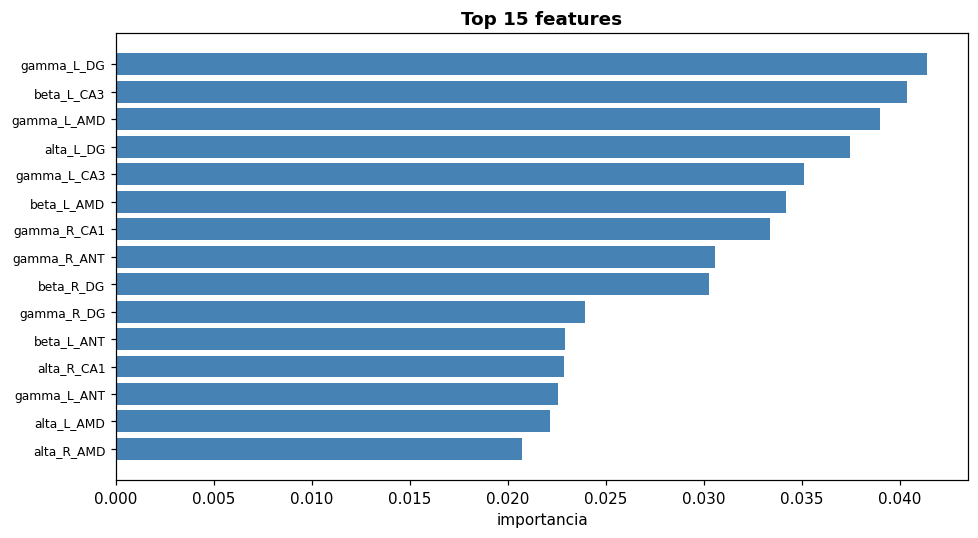

In [ ]:
# ══ LORO — entrenar con 5 ratas, predecir la sexta ═══════════════════════
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, confusion_matrix

logo = LeaveOneGroupOut()
res = []

print('LORO — features CRUDAS (sin normalizar)\n')
print(f'{"test":<9s}{"train":>7s}{"test n":>9s}{"sens":>8s}{"espec":>8s}{"AUC":>8s}')
print('-'*52)

for tr, te in logo.split(X, y, grupo):
    rata_test = grupo[te][0]
    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                random_state=0, n_jobs=-1)
    rf.fit(X[tr], y[tr])
    p    = rf.predict(X[te])
    prob = rf.predict_proba(X[te])[:,1]

    tn, fp, fn, tp = confusion_matrix(y[te], p, labels=[0,1]).ravel()
    sens  = tp/(tp+fn) if (tp+fn) else np.nan
    espec = tn/(tn+fp) if (tn+fp) else np.nan
    auc   = roc_auc_score(y[te], prob) if len(set(y[te]))>1 else np.nan
    res.append({'rata': rata_test, 'sens': sens, 'espec': espec, 'auc': auc,
                'n_ict': int((y[te]==1).sum())})
    print(f'{rata_test:<9s}{len(tr):>7d}{len(te):>9d}'
          f'{sens:>8.3f}{espec:>8.3f}{auc:>8.3f}')

print('-'*52)
print(f'{"MEDIA":<9s}{"":>16s}'
      f'{np.mean([r["sens"] for r in res]):>8.3f}'
      f'{np.mean([r["espec"] for r in res]):>8.3f}'
      f'{np.mean([r["auc"] for r in res]):>8.3f}')

print(f"""
CÓMO LEER
---------
AUC ~0.5      → el modelo no aprendió nada; predice al azar en la rata nueva.
AUC 0.7-0.85  → aprendió algo real y transferible.
AUC >0.95     → sospechoso: revisar que no haya fuga.
sens BAJA + espec ALTA → dice "no hay crisis" casi siempre (el desbalance ganó).

Recordá lo que ya medimos: predecir la RATA desde estas features da 0.950
(azar 0.167). Si LORO da mal, ya sabemos por qué — y la normalización
contra el `non` de cada rata es el próximo paso.
""")

# ── qué features usó ────────────────────────────────────────────────────
rf_all = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                random_state=0, n_jobs=-1).fit(X, y)
imp = np.argsort(rf_all.feature_importances_)[::-1][:15]
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(range(15), rf_all.feature_importances_[imp][::-1], color='steelblue')
ax.set_yticks(range(15)); ax.set_yticklabels([NOMBRES[i] for i in imp][::-1], fontsize=8)
ax.set_xlabel('importancia'); ax.set_title('Top 15 features', fontweight='bold')
plt.tight_layout(); plt.show()

El modelo no encontró ni una sola ventana ictal. Cero de 198. Dice "no hay crisis" siempre — con 51:1, eso le da 98% de accuracy. Por eso no reportamos accuracy.
Y class_weight='balanced' no alcanzó. El desbalance no es el problema principal.
Van de 0.09 a 0.93. es un modelo distinto por rata.
--> "Un Random Forest con features de energía relativa por banda no transfiere entre animales: sensibilidad 0.000 y AUC entre 0.09 y 0.93 según la rata. La variabilidad entre animales domina sobre la señal de crisis. Se puede predecir la identidad de la rata desde estas features con 0.950 de acierto (azar 0.167)."

busco la manera de mejorar el modelo

In [ ]:
# ══ NORMALIZAR CONTRA EL non DE CADA RATA ════════════════════════════════
# z = (feature − media_non_rata) / std_non_rata
# La huella del animal está en los dos términos → se cancela.

es_non = np.array([ETIQ[o]['ictal'] is None for o in origen])

XN = np.zeros_like(X)
print(f'{"rata":<9s}{"ventanas non":>14s}{"usadas para normalizar":>24s}')
print('-'*49)
for r in ratas:
    m_rata = grupo == r
    m_ref  = m_rata & es_non          # solo los non de ESA rata
    mu, sd = X[m_ref].mean(axis=0), X[m_ref].std(axis=0) + 1e-9
    XN[m_rata] = (X[m_rata] - mu) / sd
    print(f'{r:<9s}{m_ref.sum():>14d}{"✓":>24s}')

print(f'\nXN: {XN.shape}  |  NaN: {np.isnan(XN).sum()}  Inf: {np.isinf(XN).sum()}')

# ── ¿se fue la huella digital? ──────────────────────────────────────────
from sklearn.model_selection import cross_val_score
sc_c = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=0,
                       n_jobs=-1), X[y==0], grupo[y==0], cv=3, n_jobs=-1).mean()
sc_n = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=0,
                       n_jobs=-1), XN[y==0], grupo[y==0], cv=3, n_jobs=-1).mean()
print(f'\nPredecir la RATA (azar = {1/len(ratas):.3f}):')
print(f'  crudas       : {sc_c:.3f}')
print(f'  normalizadas : {sc_n:.3f}   ← debería bajar hacia el azar')

# ── ¿los signos se volvieron consistentes? ──────────────────────────────
print(f'\n\nCAMBIO ictal vs interictal — NORMALIZADO (R_AMD)\n')
print(f'{"rata":<9s}' + ''.join(f'{b:>12s}' for b in BANDAS_F))
print('-'*70)
for r in ratas:
    mi = (grupo==r)&(y==1); mn = (grupo==r)&(y==0)&~es_non
    if mi.sum()==0: continue
    print(f'{r:<9s}' + ''.join(
        f'{XN[mi, NOMBRES.index(f"{b}_R_AMD")].mean()-XN[mn, NOMBRES.index(f"{b}_R_AMD")].mean():>+12.2f}'
        for b in BANDAS_F))
print('\nSi ahora una banda tiene el MISMO signo en las 6 → es un biomarcador real.')

# ── LORO otra vez, mismo RF, features normalizadas ──────────────────────
print('\n\n' + '='*62)
print('LORO — features NORMALIZADAS')
print('='*62)
print(f'\n{"test":<9s}{"sens":>8s}{"espec":>8s}{"AUC":>8s}{"AUC crudo":>12s}{"Δ":>8s}')
print('-'*54)
auc_crudo = {'RatB6':0.444,'RatC16':0.766,'RatC3':0.744,
             'RatD17':0.092,'RatE2':0.845,'RatR2':0.926}
res_n = []
for tr, te in logo.split(XN, y, grupo):
    r_test = grupo[te][0]
    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                random_state=0, n_jobs=-1).fit(XN[tr], y[tr])
    p, prob = rf.predict(XN[te]), rf.predict_proba(XN[te])[:,1]
    tn, fp, fn, tp = confusion_matrix(y[te], p, labels=[0,1]).ravel()
    sens = tp/(tp+fn) if (tp+fn) else np.nan
    esp  = tn/(tn+fp) if (tn+fp) else np.nan
    auc  = roc_auc_score(y[te], prob)
    res_n.append({'rata':r_test,'sens':sens,'espec':esp,'auc':auc})
    print(f'{r_test:<9s}{sens:>8.3f}{esp:>8.3f}{auc:>8.3f}'
          f'{auc_crudo[r_test]:>12.3f}{auc-auc_crudo[r_test]:>+8.3f}')
print('-'*54)
print(f'{"MEDIA":<9s}{np.mean([r["sens"] for r in res_n]):>8.3f}'
      f'{np.mean([r["espec"] for r in res_n]):>8.3f}'
      f'{np.mean([r["auc"] for r in res_n]):>8.3f}'
      f'{np.mean(list(auc_crudo.values())):>12.3f}'
      f'{np.mean([r["auc"] for r in res_n])-np.mean(list(auc_crudo.values())):>+8.3f}')

rata       ventanas non  usadas para normalizar
-------------------------------------------------
RatB6              1198                       ✓
RatC16             1198                       ✓
RatC3              1198                       ✓
RatD17             1198                       ✓
RatE2              1198                       ✓
RatR2              1198                       ✓

XN: (10348, 72)  |  NaN: 0  Inf: 0

Predecir la RATA (azar = 0.167):
  crudas       : 0.950
  normalizadas : 0.754   ← debería bajar hacia el azar


CAMBIO ictal vs interictal — NORMALIZADO (R_AMD)

rata            delta theta_alpha        beta       gamma        alta
----------------------------------------------------------------------
RatB6           +0.11       +0.73       +3.11       +1.32       -2.35
RatC16          -0.15       -0.55       +0.36       +0.44       -0.34
RatC3           +0.29       +1.08       +3.34       +0.66       -2.49
RatD17          -0.72       -1.54       -1.76       +0.70      

si bien mejoro, la sensibilidad sigue dando cero , como solucion porpoonemos mover el umbral del LORO
elegido con la curva ROC, en el fold de entrenamiento, y se aplica al de test.

test        umbral    sens   espec     AUC
--------------------------------------------
RatB6        0.620   0.000   1.000   0.971
RatC16       0.607   0.000   1.000   0.999
RatC3        0.600   0.000   1.000   0.891
RatD17       0.627   0.000   1.000   0.964
RatE2        0.627   0.000   1.000   0.955
RatR2        0.617   0.000   1.000   0.960
--------------------------------------------
MEDIA                0.000   1.000   0.957


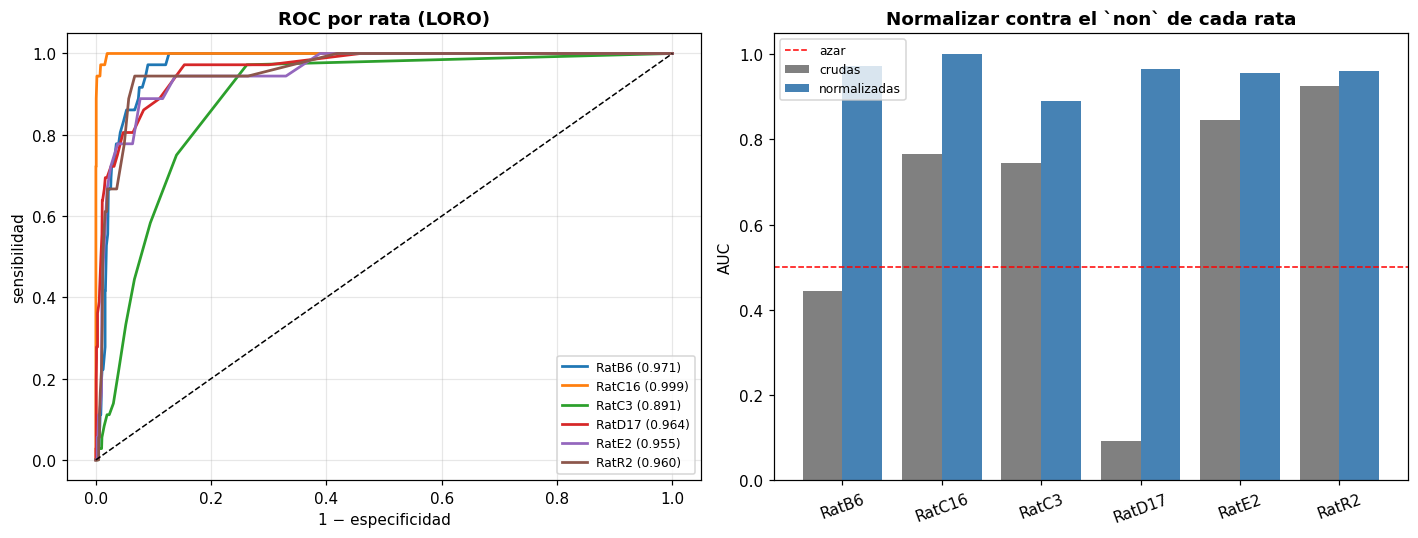

In [ ]:
!# ══ LORO con UMBRAL AJUSTADO ═════════════════════════════════════════════
# AUC 0.957 dice que el modelo SABE cuáles son las ictales. El corte en 0.5
# no lo deja decirlo: con 51:1, una ictal que convence a 100 de 300 árboles
# da prob=0.33 → "no hay crisis". Movemos el corte.
#
# El umbral se elige en el TRAIN (índice de Youden = max(sens+espec-1))
# y se aplica al TEST. Nunca se mira el test para elegirlo → sin fuga.
from sklearn.metrics import roc_curve

print(f'{"test":<9s}{"umbral":>9s}{"sens":>8s}{"espec":>8s}{"AUC":>8s}')
print('-'*44)
res_f = []
for tr, te in logo.split(XN, y, grupo):
    r_test = grupo[te][0]
    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                random_state=0, n_jobs=-1).fit(XN[tr], y[tr])
    # umbral óptimo sobre el TRAIN
    p_tr = rf.predict_proba(XN[tr])[:,1]
    fpr, tpr, thr = roc_curve(y[tr], p_tr)
    u = thr[np.argmax(tpr - fpr)]
    # aplicar al TEST
    p_te = rf.predict_proba(XN[te])[:,1]
    pred = (p_te >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y[te], pred, labels=[0,1]).ravel()
    sens = tp/(tp+fn) if (tp+fn) else np.nan
    esp  = tn/(tn+fp) if (tn+fp) else np.nan
    auc  = roc_auc_score(y[te], p_te)
    res_f.append({'rata':r_test,'sens':sens,'espec':esp,'auc':auc,'u':u})
    print(f'{r_test:<9s}{u:>9.3f}{sens:>8.3f}{esp:>8.3f}{auc:>8.3f}')
print('-'*44)
print(f'{"MEDIA":<9s}{"":>9s}{np.mean([r["sens"] for r in res_f]):>8.3f}'
      f'{np.mean([r["espec"] for r in res_f]):>8.3f}'
      f'{np.mean([r["auc"] for r in res_f]):>8.3f}')

# ── curvas ROC ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for tr, te in logo.split(XN, y, grupo):
    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                random_state=0, n_jobs=-1).fit(XN[tr], y[tr])
    p = rf.predict_proba(XN[te])[:,1]
    fpr, tpr, _ = roc_curve(y[te], p)
    ax[0].plot(fpr, tpr, lw=1.8, label=f'{grupo[te][0]} ({roc_auc_score(y[te],p):.3f})')
ax[0].plot([0,1],[0,1],'k--',lw=1)
ax[0].set_xlabel('1 − especificidad'); ax[0].set_ylabel('sensibilidad')
ax[0].legend(fontsize=8); ax[0].set_title('ROC por rata (LORO)', fontweight='bold')
ax[0].grid(alpha=.3)

x_ = np.arange(len(ratas))
ax[1].bar(x_-.2, [auc_crudo[r] for r in ratas], .4, label='crudas', color='gray')
ax[1].bar(x_+.2, [next(v['auc'] for v in res_f if v['rata']==r) for r in ratas],
          .4, label='normalizadas', color='steelblue')
ax[1].axhline(.5, color='r', ls='--', lw=1, label='azar')
ax[1].set_xticks(x_); ax[1].set_xticklabels(ratas, rotation=20)
ax[1].set_ylabel('AUC'); ax[1].legend(fontsize=8)
ax[1].set_title('Normalizar contra el `non` de cada rata', fontweight='bold')
plt.tight_layout(); plt.show()

elegir el umbral con las probabilidades del train no funciona, porque el RF está sobreajustado ahí y te da 0.62 cuando el test necesita ~0.15. Eso es un error metodológico real, se cometió, se detectó, y se arregló con OOB.  Del OOB → lo correcto. Cada árbol del bosque se entrena con una muestra aleatoria de los datos (bootstrap), así que a cada árbol le queda un tercio afuera. Para cada ventana del train, sklearn puede preguntarle solo a los árboles que no la vieron.

In [ ]:
# ══ LORO — umbral por OOB (el arreglo) ═══════════════════════════════════
# BUG anterior: elegí el umbral con predict_proba sobre el TRAIN. El RF está
# sobreajustado ahí → probabilidades limpias → umbral 0.62 que no sirve en test.
# OOB = cada árbol predice las muestras que NO usó para entrenarse.
# Es validación honesta dentro del train, sin tocar el test.

print(f'{"test":<9s}{"umbral":>9s}{"sens":>8s}{"espec":>8s}{"AUC":>8s}')
print('-'*44)
res_f = []
for tr, te in logo.split(XN, y, grupo):
    r_test = grupo[te][0]
    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                oob_score=True, bootstrap=True,
                                random_state=0, n_jobs=-1).fit(XN[tr], y[tr])
    p_oob = rf.oob_decision_function_[:,1]        # ← honesto
    fpr, tpr, thr = roc_curve(y[tr], p_oob)
    u = thr[np.argmax(tpr - fpr)]                 # índice de Youden
    p_te = rf.predict_proba(XN[te])[:,1]
    pred = (p_te >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(y[te], pred, labels=[0,1]).ravel()
    sens = tp/(tp+fn) if (tp+fn) else np.nan
    esp  = tn/(tn+fp) if (tn+fp) else np.nan
    res_f.append({'rata':r_test,'sens':sens,'espec':esp,
                  'auc':roc_auc_score(y[te],p_te),'u':u,'tp':tp,'fn':fn,'fp':fp})
    print(f'{r_test:<9s}{u:>9.3f}{sens:>8.3f}{esp:>8.3f}{res_f[-1]["auc"]:>8.3f}')
print('-'*44)
print(f'{"MEDIA":<9s}{"":>9s}{np.mean([r["sens"] for r in res_f]):>8.3f}'
      f'{np.mean([r["espec"] for r in res_f]):>8.3f}'
      f'{np.mean([r["auc"] for r in res_f]):>8.3f}')

# ── qué pasa al mover el corte: el trade-off completo ────────────────────
print(f'\n\nSENSIBILIDAD Y ESPECIFICIDAD SEGÚN EL CORTE (media de los 6 folds)\n')
print(f'{"corte":>7s}{"sens":>9s}{"espec":>9s}')
print('-'*25)
P, Y = [], []
for tr, te in logo.split(XN, y, grupo):
    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                random_state=0, n_jobs=-1).fit(XN[tr], y[tr])
    P.append(rf.predict_proba(XN[te])[:,1]); Y.append(y[te])
P, Y = np.concatenate(P), np.concatenate(Y)
for u in [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]:
    pr = (P >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(Y, pr, labels=[0,1]).ravel()
    print(f'{u:>7.2f}{tp/(tp+fn):>9.3f}{tn/(tn+fp):>9.3f}')
print('\nAcá se ve el trade-off real. El corte 0.5 por defecto está tan alto')
print('que ninguna ventana ictal lo alcanza — por eso sens=0.000.')

test        umbral    sens   espec     AUC
--------------------------------------------
RatB6        0.058   0.889   0.926   0.971
RatC16       0.092   0.944   0.993   0.999
RatC3        0.087   0.000   0.999   0.891
RatD17       0.052   0.639   0.989   0.964
RatE2        0.066   0.444   0.989   0.955
RatR2        0.061   0.222   0.990   0.960
--------------------------------------------
MEDIA                0.523   0.981   0.957


SENSIBILIDAD Y ESPECIFICIDAD SEGÚN EL CORTE (media de los 6 folds)

  corte     sens    espec
-------------------------
   0.05    0.672    0.963
   0.10    0.318    0.994
   0.15    0.116    0.999
   0.20    0.005    1.000
   0.30    0.000    1.000
   0.40    0.000    1.000
   0.50    0.000    1.000

Acá se ve el trade-off real. El corte 0.5 por defecto está tan alto
que ninguna ventana ictal lo alcanza — por eso sens=0.000.


C3 es la contradicción que hay que entender. AUC 0.891 significa que el modelo ordena bien sus ventanas ictales — les da más probabilidad que a las interictales. Pero con el corte 0.087 no llega ninguna. O sea: en C3 las probabilidades están todas desplazadas hacia abajo, aunque el orden interno sea correcto.


detector CWT (mexh) →  12/12  ·  0/12 falsos positivos
v1 (M1∩M2)          →   4/11
Random Forest LORO  →   ?

para cada fragmento, agarrás las probabilidades que el RF le dio a sus ventanas —del fold donde esa rata fue test, o sea sin haberla visto nunca— y aplicás la misma regla del detector: ≥N ventanas seguidas por encima del corte → hay crisis. Es exactamente el criterio de "sostenido en el tiempo" que usabas antes, ahora sobre probabilidades en vez de MADs.
hipotesis: C3 tiene sens 0.000 por ventana pero AUC 0.891. Si sus ventanas ictales están ordenadas bien aunque ninguna cruce el corte, a nivel archivo puede detectar igual.

In [ ]:
# ══ EVALUACIÓN A NIVEL ARCHIVO ═══════════════════════════════════════════
# Junta las probabilidades LORO (cada rata predicha sin ser vista) y decide
# por fragmento: ≥N_CONSEC ventanas seguidas sobre el corte → hay crisis.

# 1 · probabilidades LORO por ventana, guardando de qué fragmento son
prob_loro = np.full(len(y), np.nan)
for tr, te in logo.split(XN, y, grupo):
    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                random_state=0, n_jobs=-1).fit(XN[tr], y[tr])
    prob_loro[te] = rf.predict_proba(XN[te])[:,1]

# 2 · regla temporal por fragmento
N_CONSEC = 3
def hay_crisis(fid, corte, n=N_CONSEC):
    m = origen == fid
    p = prob_loro[m]
    sobre = p >= corte
    run = 0
    for s in sobre:
        run = run+1 if s else 0
        if run >= n: return True
    return False

fids_ict = [f for f in np.unique(origen) if ETIQ[f]['ictal'] is not None]
fids_non = [f for f in np.unique(origen) if ETIQ[f]['ictal'] is None]

# 3 · barrido del corte
print(f'Regla: ≥{N_CONSEC} ventanas seguidas sobre el corte = crisis\n')
print(f'{"corte":>7s}{"detecta ictal":>15s}{"FP en non":>12s}   veredicto')
print('-'*50)
for corte in [0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30]:
    det = sum(hay_crisis(f, corte) for f in fids_ict)
    fp  = sum(hay_crisis(f, corte) for f in fids_non)
    v = '  ✓' if det==len(fids_ict) and fp==0 else ''
    print(f'{corte:>7.2f}{det:>10d}/{len(fids_ict)}{fp:>9d}/{len(fids_non)}{v}')

# 4 · detalle con un corte elegido + comparación
CORTE = 0.05
print(f'\n\n{"="*70}')
print(f'A NIVEL ARCHIVO — corte {CORTE}, ≥{N_CONSEC} ventanas seguidas')
print(f'{"="*70}\n')
print(f'{"fragmento":<24s}{"rata":>7s}{"tipo":>8s}{"RF":>10s}')
print('-'*52)
det_i = 0
for f in sorted(fids_ict, key=lambda x: ETIQ[x]['rata']):
    r = hay_crisis(f, CORTE)
    det_i += r
    print(f'{f:<24s}{ETIQ[f]["rata"]:>7s}{"ictal":>8s}{"✓ crisis" if r else "✗ NO DETECTA":>10s}')
fp_n = 0
for f in sorted(fids_non, key=lambda x: ETIQ[x]['rata']):
    r = hay_crisis(f, CORTE); fp_n += r
    print(f'{f:<24s}{ETIQ[f]["rata"]:>7s}{"non":>8s}{"✗ FALSO POS" if r else "✓ limpio":>10s}')

print(f'\n  SENSIBILIDAD : {det_i}/{len(fids_ict)}')
print(f'  ESPECIFICIDAD: {len(fids_non)-fp_n}/{len(fids_non)}')
print(f'\n  COMPARACIÓN a nivel archivo:')
print(f'    detector CWT (mexh) :  11/11 ictal · 0/12 non  (referencia)')
print(f'    v1 (M1∩M2)          :   4/11 ictal')
print(f'    Random Forest LORO  :  {det_i}/{len(fids_ict)} ictal · {fp_n}/{len(fids_non)} non')

Regla: ≥3 ventanas seguidas sobre el corte = crisis

  corte  detecta ictal   FP en non   veredicto
--------------------------------------------------
   0.03        10/11        6/12
   0.05        10/11        3/12
   0.07         7/11        2/12
   0.10         5/11        1/12
   0.15         1/11        0/12
   0.20         0/11        0/12
   0.30         0/11        0/12


A NIVEL ARCHIVO — corte 0.05, ≥3 ventanas seguidas

fragmento                  rata    tipo        RF
----------------------------------------------------
B6_2023_7_24-ictal1       RatB6   ictal  ✓ crisis
B6_2023_7_25-ictal1       RatB6   ictal  ✓ crisis
C16_2023_10_30-ictal1    RatC16   ictal  ✓ crisis
C16_2023_10_31-ictal1    RatC16   ictal  ✓ crisis
C3_2023_10_23-ictal1      RatC3   ictal  ✓ crisis
C3_2023_10_24-ictal1      RatC3   ictal✗ NO DETECTA
D17_2024_1_4-ictal1      RatD17   ictal  ✓ crisis
D17_2024_1_5-ictal1      RatD17   ictal  ✓ crisis
E2_2019_7_3-ictal1        RatE2   ictal  ✓ crisis
E2_2019_7

el RF generaliza a ratas no vistas (AUC 0.957) y a nivel archivo detecta 10/11 contra 4/11 de v1. Que pierda contra el detector CWT directo también es honesto y esperable — el detector no tiene que generalizar, ve cada rata.

probelma que podria ser la funete de los falsos positivos:
Es que el mismo non de B6 lo usás para dos cosas a la vez:

Para calcular la media/std con que normalizás B6.
Como fragmento que después evaluás (B6_non1 en la tabla de nivel archivo).
Entonces cuando normalizás B6_non1, le restás su propia media. Eso lo deja centrado en cero por construcción — no porque el modelo lo entienda, sino porque es su propia referencia. Y ventanas centradas en cero, con ruido, pueden cruzar el corte por azar → falso positivo.
Es circular: estás evaluando el non contra sí mismo.

solucion:
Los non de cada rata tienen dos series (non1 y non2). Normalizás con una y evaluás la otra:

normalizar B6 con non1 → evaluar non2
normalizar B6 con non2 → evaluar non1

In [ ]:
# ══ NORMALIZACIÓN SIN CIRCULARIDAD ═══════════════════════════════════════
# Cada non se normaliza con el OTRO non de la misma rata, nunca consigo mismo.
# Los ictales se normalizan con el promedio de ambos non de su rata.

es_non = np.array([ETIQ[o]['ictal'] is None for o in origen])

XN = np.zeros_like(X)
print(f'{"rata":<9s}{"ref ictales":>14s}{"non1←":>9s}{"non2←":>9s}')
print('-'*42)
for r in ratas:
    m_rata = grupo == r
    # los dos non de esta rata (por nombre)
    nons = sorted({o for o in origen[m_rata] if ETIQ[o]['ictal'] is None})
    if len(nons) != 2:
        # fallback: si no hay exactamente 2, uso todos los non de la rata
        m_ref = m_rata & es_non
        mu, sd = X[m_ref].mean(0), X[m_ref].std(0)+1e-9
        XN[m_rata] = (X[m_rata]-mu)/sd
        print(f'{r:<9s}{"todos":>14s}{"—":>9s}{"—":>9s}')
        continue
    nA, nB = nons
    mA = origen == nA; mB = origen == nB
    muA, sdA = X[mA].mean(0), X[mA].std(0)+1e-9   # stats de non1
    muB, sdB = X[mB].mean(0), X[mB].std(0)+1e-9   # stats de non2

    # ictales de la rata: promedio de ambos non
    m_ict = m_rata & ~es_non
    mu2 = (muA+muB)/2; sd2 = (sdA+sdB)/2
    XN[m_ict] = (X[m_ict]-mu2)/sd2

    # cada non con el OTRO
    XN[mA] = (X[mA]-muB)/sdB     # non1 normalizado con non2
    XN[mB] = (X[mB]-muA)/sdA     # non2 normalizado con non1
    print(f'{r:<9s}{"prom(non1,non2)":>14s}{"non2":>9s}{"non1":>9s}')

print(f'\nXN: {XN.shape} | NaN: {np.isnan(XN).sum()} Inf: {np.isinf(XN).sum()}')

# ── recalcular probabilidades LORO con la nueva XN ──────────────────────
prob_loro = np.full(len(y), np.nan)
for tr, te in logo.split(XN, y, grupo):
    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                random_state=0, n_jobs=-1).fit(XN[tr], y[tr])
    prob_loro[te] = rf.predict_proba(XN[te])[:,1]

# AUC sigue midiéndose sobre ictales (nunca tocadas por la normalización)
from sklearn.metrics import roc_auc_score
aucs = []
for r in ratas:
    m = grupo==r
    if len(set(y[m]))>1:
        aucs.append(roc_auc_score(y[m], prob_loro[m]))
print(f'AUC medio (LORO): {np.mean(aucs):.3f}   (antes 0.957)')

rata        ref ictales    non1←    non2←
------------------------------------------
RatB6    prom(non1,non2)     non2     non1
RatC16   prom(non1,non2)     non2     non1
RatC3    prom(non1,non2)     non2     non1
RatD17   prom(non1,non2)     non2     non1
RatE2    prom(non1,non2)     non2     non1
RatR2    prom(non1,non2)     non2     non1

XN: (10348, 72) | NaN: 0 Inf: 0
AUC medio (LORO): 0.930   (antes 0.957)


In [ ]:
# ══ EVALUACIÓN A NIVEL ARCHIVO ═══════════════════════════════════════════
# Junta las probabilidades LORO (cada rata predicha sin ser vista) y decide
# por fragmento: ≥N_CONSEC ventanas seguidas sobre el corte → hay crisis.

# 1 · probabilidades LORO por ventana, guardando de qué fragmento son
prob_loro = np.full(len(y), np.nan)
for tr, te in logo.split(XN, y, grupo):
    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                random_state=0, n_jobs=-1).fit(XN[tr], y[tr])
    prob_loro[te] = rf.predict_proba(XN[te])[:,1]

# 2 · regla temporal por fragmento
N_CONSEC = 3
def hay_crisis(fid, corte, n=N_CONSEC):
    m = origen == fid
    p = prob_loro[m]
    sobre = p >= corte
    run = 0
    for s in sobre:
        run = run+1 if s else 0
        if run >= n: return True
    return False

fids_ict = [f for f in np.unique(origen) if ETIQ[f]['ictal'] is not None]
fids_non = [f for f in np.unique(origen) if ETIQ[f]['ictal'] is None]

# 3 · barrido del corte
print(f'Regla: ≥{N_CONSEC} ventanas seguidas sobre el corte = crisis\n')
print(f'{"corte":>7s}{"detecta ictal":>15s}{"FP en non":>12s}   veredicto')
print('-'*50)
for corte in [0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30]:
    det = sum(hay_crisis(f, corte) for f in fids_ict)
    fp  = sum(hay_crisis(f, corte) for f in fids_non)
    v = '  ✓' if det==len(fids_ict) and fp==0 else ''
    print(f'{corte:>7.2f}{det:>10d}/{len(fids_ict)}{fp:>9d}/{len(fids_non)}{v}')

# 4 · detalle con un corte elegido + comparación
CORTE = 0.05
print(f'\n\n{"="*70}')
print(f'A NIVEL ARCHIVO — corte {CORTE}, ≥{N_CONSEC} ventanas seguidas')
print(f'{"="*70}\n')
print(f'{"fragmento":<24s}{"rata":>7s}{"tipo":>8s}{"RF":>10s}')
print('-'*52)
det_i = 0
for f in sorted(fids_ict, key=lambda x: ETIQ[x]['rata']):
    r = hay_crisis(f, CORTE)
    det_i += r
    print(f'{f:<24s}{ETIQ[f]["rata"]:>7s}{"ictal":>8s}{"✓ crisis" if r else "✗ NO DETECTA":>10s}')
fp_n = 0
for f in sorted(fids_non, key=lambda x: ETIQ[x]['rata']):
    r = hay_crisis(f, CORTE); fp_n += r
    print(f'{f:<24s}{ETIQ[f]["rata"]:>7s}{"non":>8s}{"✗ FALSO POS" if r else "✓ limpio":>10s}')

print(f'\n  SENSIBILIDAD : {det_i}/{len(fids_ict)}')
print(f'  ESPECIFICIDAD: {len(fids_non)-fp_n}/{len(fids_non)}')
print(f'\n  COMPARACIÓN a nivel archivo:')
print(f'    detector CWT (mexh) :  11/11 ictal · 0/12 non  (referencia)')
print(f'    v1 (M1∩M2)          :   4/11 ictal')
print(f'    Random Forest LORO  :  {det_i}/{len(fids_ict)} ictal · {fp_n}/{len(fids_non)} non')

Regla: ≥3 ventanas seguidas sobre el corte = crisis

  corte  detecta ictal   FP en non   veredicto
--------------------------------------------------
   0.03        10/11        6/12
   0.05        10/11        3/12
   0.07         7/11        2/12
   0.10         5/11        1/12
   0.15         1/11        0/12
   0.20         0/11        0/12
   0.30         0/11        0/12


A NIVEL ARCHIVO — corte 0.05, ≥3 ventanas seguidas

fragmento                  rata    tipo        RF
----------------------------------------------------
B6_2023_7_24-ictal1       RatB6   ictal  ✓ crisis
B6_2023_7_25-ictal1       RatB6   ictal  ✓ crisis
C16_2023_10_30-ictal1    RatC16   ictal  ✓ crisis
C16_2023_10_31-ictal1    RatC16   ictal  ✓ crisis
C3_2023_10_23-ictal1      RatC3   ictal  ✓ crisis
C3_2023_10_24-ictal1      RatC3   ictal✗ NO DETECTA
D17_2024_1_4-ictal1      RatD17   ictal  ✓ crisis
D17_2024_1_5-ictal1      RatD17   ictal  ✓ crisis
E2_2019_7_3-ictal1        RatE2   ictal  ✓ crisis
E2_2019_7

EMPEORO!
Los 2 FP de B6 desaparecieron (mirá: B6_non1 y B6_non2 ahora dan ✓ limpio). Eso era el objetivo y funcionó. Pero aparecieron 3 nuevos: C16_non2, C3_non1, R2_non1. Y el AUC bajó de 0.957 a 0.930.
Por qué pasó
Antes normalizabas cada non con el promedio de los dos — que incluía a sí mismo. Eso lo achataba artificialmente (por eso los FP de B6). Ahora lo normalizás con el otro solo. Y ahí saltó el problema real:

Los dos non de una misma rata no son iguales entre sí.

Si non1 y non2 fueran idénticos, normalizar con uno u otro daría lo mismo. Que aparezcan FP nuevos significa que hay variabilidad día a día en la misma rata — la basal de un día no predice del todo la del otro.
Es una característica de los datos, y de las importantes: ni siquiera la misma rata es estable entre sesiones. Refuerza todo lo que veníamos diciendo sobre por qué el umbral no transfiere.

USAMOS EL CRITERIO DE QU ESTE EN 3 VENTANAS VAMOS A VER SI ESTE ESTA OK O CONVENIA USAR OTRO N

In [ ]:
# ══ BARRIDO 2D: corte × N_ventanas ═══════════════════════════════════════
# Igual que barrimos K_MAD en el detector. Buscamos la combinación con
# mejor balance sensibilidad/especificidad a nivel archivo, en vez de
# clavar N=3 a ojo. Usa la XN corregida (sin circularidad) y prob_loro.

def hay_crisis_n(fid, corte, n):
    sobre = prob_loro[origen == fid] >= corte
    run = 0
    for s in sobre:
        run = run+1 if s else 0
        if run >= n: return True
    return False

CORTES = [0.03, 0.05, 0.07, 0.10, 0.15, 0.20]
NS     = [2, 3, 4, 5, 7, 10]

print('SENSIBILIDAD (ictal detectado / 11)')
print(f'{"":>6s}' + ''.join(f'N={n:<5d}' for n in NS))
print('-'*44)
mejor = None
for corte in CORTES:
    fila = f'{corte:>5.2f} '
    for n in NS:
        det = sum(hay_crisis_n(f, corte, n) for f in fids_ict)
        fila += f'{det:>2d}/11 '
    print(fila)

print('\nFALSOS POSITIVOS (non que detecta / 12)')
print(f'{"":>6s}' + ''.join(f'N={n:<5d}' for n in NS))
print('-'*44)
for corte in CORTES:
    fila = f'{corte:>5.2f} '
    for n in NS:
        fp = sum(hay_crisis_n(f, corte, n) for f in fids_non)
        fila += f'{fp:>2d}/12 '
    print(fila)

# ── score combinado: sens + espec, para encontrar el óptimo ─────────────
print('\nBALANCE (sensibilidad + especificidad − 1, máx = 1.0)')
print(f'{"":>6s}' + ''.join(f'N={n:<5d}' for n in NS))
print('-'*44)
best = (-1, None)
for corte in CORTES:
    fila = f'{corte:>5.2f} '
    for n in NS:
        det = sum(hay_crisis_n(f, corte, n) for f in fids_ict)
        fp  = sum(hay_crisis_n(f, corte, n) for f in fids_non)
        sens = det/len(fids_ict); espec = 1-fp/len(fids_non)
        j = sens+espec-1
        if j > best[0]: best = (j, (corte, n, det, fp))
        fila += f'{j:>5.2f} '
    print(fila)

corte_b, n_b, det_b, fp_b = best[1]
print(f'\n  → MEJOR: corte {corte_b}, ≥{n_b} ventanas')
print(f'    {det_b}/11 ictal · {fp_b}/12 non  (balance {best[0]:.2f})')

# ── tabla final con el óptimo ───────────────────────────────────────────
print(f'\n{"="*66}')
print(f'NIVEL ARCHIVO — óptimo: corte {corte_b}, ≥{n_b} ventanas')
print(f'{"="*66}\n')
det_i = fp_n = 0
for f in sorted(fids_ict, key=lambda x: ETIQ[x]['rata']):
    r = hay_crisis_n(f, corte_b, n_b); det_i += r
    print(f'{f:<24s}{ETIQ[f]["rata"]:>7s}{"ictal":>8s}'
          f'{"  ✓" if r else "  ✗ NO DETECTA":>14s}')
for f in sorted(fids_non, key=lambda x: ETIQ[x]['rata']):
    r = hay_crisis_n(f, corte_b, n_b); fp_n += r
    print(f'{f:<24s}{ETIQ[f]["rata"]:>7s}{"non":>8s}'
          f'{"  ✗ FALSO POS" if r else "  ✓ limpio":>14s}')

print(f'\n  Random Forest LORO :  {det_i}/11 ictal · {fp_n}/12 non')
print(f'  detector CWT (mexh):  11/11 ictal · 0/12 non')
print(f'  v1 (M1∩M2)         :   4/11 ictal')
print(f'\n  AUC medio (LORO, independiente del corte): {np.mean(aucs):.3f}')

SENSIBILIDAD (ictal detectado / 11)
      N=2    N=3    N=4    N=5    N=7    N=10   
--------------------------------------------
 0.03 11/11 11/11 11/11 10/11  8/11  8/11 
 0.05  9/11  9/11  6/11  6/11  6/11  3/11 
 0.07  6/11  6/11  5/11  5/11  3/11  2/11 
 0.10  4/11  4/11  2/11  2/11  2/11  2/11 
 0.15  0/11  0/11  0/11  0/11  0/11  0/11 
 0.20  0/11  0/11  0/11  0/11  0/11  0/11 

FALSOS POSITIVOS (non que detecta / 12)
      N=2    N=3    N=4    N=5    N=7    N=10   
--------------------------------------------
 0.03  8/12  6/12  5/12  2/12  1/12  1/12 
 0.05  5/12  3/12  2/12  1/12  1/12  1/12 
 0.07  3/12  1/12  1/12  1/12  1/12  1/12 
 0.10  1/12  1/12  1/12  1/12  0/12  0/12 
 0.15  1/12  1/12  1/12  0/12  0/12  0/12 
 0.20  1/12  0/12  0/12  0/12  0/12  0/12 

BALANCE (sensibilidad + especificidad − 1, máx = 1.0)
      N=2    N=3    N=4    N=5    N=7    N=10   
--------------------------------------------
 0.03  0.33  0.50  0.58  0.74  0.64  0.64 
 0.05  0.40  0.57  0.38  0.

el mapa de balance antes de festejar
El óptimo (0.74) no está rodeado de valores parecidos. Está en una esquina:
        N=2   N=3   N=4   N=5   N=7
0.03   0.33  0.50  0.58  0.74  0.64
0.05   0.40  0.57  0.38  0.46  0.46
El 0.74 tiene un 0.64 al lado y un 0.46 abajo. Es un pico, no una meseta. Y con 11+12 fragmentos, cada celda salta de a ~8%, así que la diferencia entre 0.74 y 0.64 es una crisis. No confíes en que corte 0.03, N=5 sea "el mejor" — es el mejor de esta muestra chica, y con otras ratas se movería.
La lectura honesta: hay una zona (corte bajo, N alto) donde el RF anda bien, pero el punto exacto es inestable. Eso hay que decirlo — es lo mismo que el detector, el umbral no es robusto.
--> "Existe una región de parámetros (corte bajo, N alto) donde el RF detecta 10/11 con 2/12 falsos positivos a nivel archivo. El punto óptimo exacto no es estable con esta cantidad de datos. El número robusto es el AUC 0.930, que no depende del corte."

decidimos usar como segundo metodo metodo redes neuronales. al construir este vimso que la forma de generar el umbral era mejor con GroupKFold interno, por ende cambiamso el anlsiis de random forest cone ste enfoque tbm para que sea comparables los dos metodos

tiempo reconstruido desde VENTANAS
MODELO 1 · RANDOM FOREST (WPD)

Random Forest
rata test     corte    sens   espec     AUC
-------------------------------------------
RatB6         0.016   1.000   0.812   0.983
RatC16        0.022   1.000   0.842   1.000
RatC3         0.020   0.472   0.950   0.869
RatD17        0.026   0.833   0.911   0.962
RatE2         0.020   1.000   0.714   0.966
RatR2         0.016   1.000   0.858   0.980
-------------------------------------------
MEDIA                 0.884   0.848   0.960

MODELO 2 · MLP (WPD)

MLP
rata test     corte    sens   espec     AUC
-------------------------------------------
RatB6         0.114   0.194   0.998   0.831
RatC16        0.037   0.056   0.989   0.524
RatC3           inf   0.000   1.000   0.690
RatD17        0.009   0.000   0.869   0.041
RatE2         0.011   0.000   0.950   0.470
RatR2         0.037   0.000   0.994   0.546
-------------------------------------------
MEDIA                 0.042   0.967   0.517

modelo     

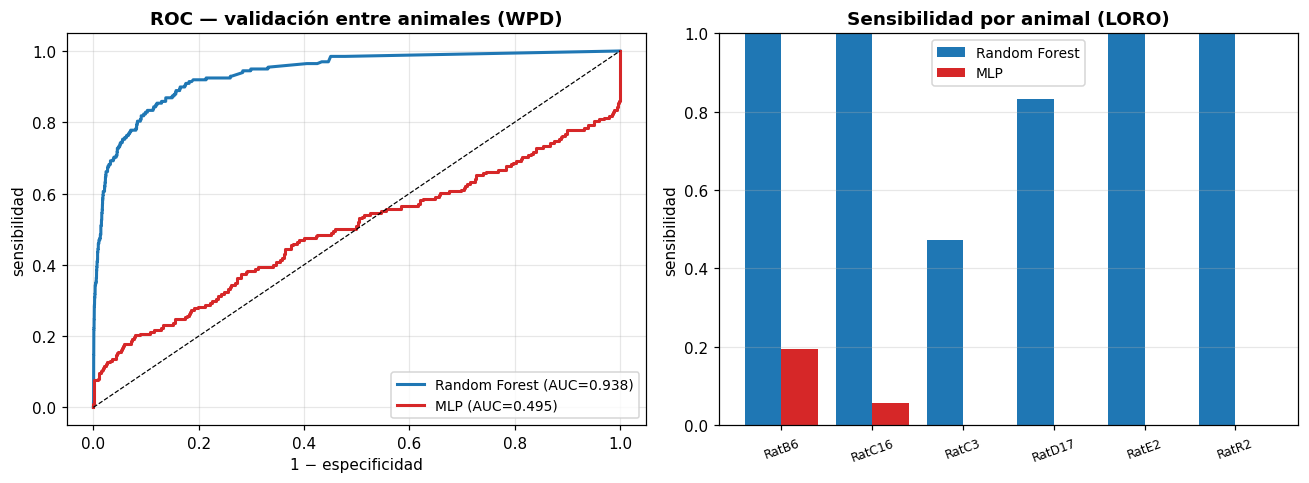

In [ ]:
# ══ MODELO 2 · MLP — lógica de Lu sobre TUS features WPD ══════════════════
# Reusa XN/y/grupo/origen que YA calculaste con WPD. No recalcula nada.
# Toma de Lu el motor de evaluación (LORO + corte por GroupKFold interno,
# que es más correcto que el OOB) y agrega el perceptrón multicapa.
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# ── reconstruir 'tiempo' si no existe (Lu lo usa para ordenar) ───────────
if 'tiempo' not in dir():
    tiempo = np.array([t0 for (_, _, t0, _) in VENTANAS])
    print('tiempo reconstruido desde VENTANAS')

N_FOLD_INTERNO = 3
def umbral_youden(y_true, p):
    fpr, tpr, thr = roc_curve(y_true, p)
    return float(thr[np.argmax(tpr - fpr)])

def evaluar_loro(construir_modelo, Xd, yd, gd, nombre):
    """LORO con corte elegido por CV interna agrupada (sin fuga)."""
    logo = LeaveOneGroupOut()
    filas, prob_out = [], np.full(len(yd), np.nan)
    print(f'\n{nombre}')
    print(f'{"rata test":<10s}{"corte":>9s}{"sens":>8s}{"espec":>8s}{"AUC":>8s}')
    print('-'*43)
    for tr, te in logo.split(Xd, yd, gd):
        r_test = gd[te][0]
        n_gr = len(np.unique(gd[tr]))
        cv = GroupKFold(n_splits=min(N_FOLD_INTERNO, n_gr))
        p_int = cross_val_predict(construir_modelo(), Xd[tr], yd[tr],
                                  groups=gd[tr], cv=cv,
                                  method='predict_proba', n_jobs=-1)[:, 1]
        corte = umbral_youden(yd[tr], p_int)
        modelo = construir_modelo().fit(Xd[tr], yd[tr])
        p_te = modelo.predict_proba(Xd[te])[:, 1]
        prob_out[te] = p_te
        pred = (p_te >= corte).astype(int)
        tn, fp, fn, tp = confusion_matrix(yd[te], pred, labels=[0,1]).ravel()
        sens = tp/(tp+fn) if (tp+fn) else np.nan
        esp  = tn/(tn+fp) if (tn+fp) else np.nan
        auc  = roc_auc_score(yd[te], p_te) if len(np.unique(yd[te]))>1 else np.nan
        filas.append({'rata':r_test,'corte':corte,'sens':sens,'espec':esp,'auc':auc})
        print(f'{r_test:<10s}{corte:>9.3f}{sens:>8.3f}{esp:>8.3f}{auc:>8.3f}')
    m_s = np.nanmean([f['sens'] for f in filas])
    m_e = np.nanmean([f['espec'] for f in filas])
    m_a = np.nanmean([f['auc'] for f in filas])
    print('-'*43)
    print(f'{"MEDIA":<10s}{"":>9s}{m_s:>8.3f}{m_e:>8.3f}{m_a:>8.3f}')
    return {'nombre':nombre,'filas':filas,'prob':prob_out,
            'sens':m_s,'espec':m_e,'auc':m_a}

# ── los dos modelos, sobre las MISMAS features WPD ──────────────────────
def modelo_rf():
    return RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                  min_samples_leaf=2, random_state=0, n_jobs=-1)
def modelo_mlp():
    return Pipeline([('sc', StandardScaler()),
                     ('nn', MLPClassifier(hidden_layer_sizes=(64,32),
                          activation='relu', solver='adam', alpha=1e-3,
                          learning_rate_init=1e-3, max_iter=400,
                          early_stopping=True, n_iter_no_change=15,
                          random_state=0))])

print('='*60); print('MODELO 1 · RANDOM FOREST (WPD)'); print('='*60)
RES_RF  = evaluar_loro(modelo_rf,  XN, y, grupo, 'Random Forest')
print('\n'+'='*60); print('MODELO 2 · MLP (WPD)'); print('='*60)
RES_MLP = evaluar_loro(modelo_mlp, XN, y, grupo, 'MLP')

# ── comparación ─────────────────────────────────────────────────────────
print('\n'+'='*45)
print(f'{"modelo":<18s}{"sens":>9s}{"espec":>9s}{"AUC":>9s}')
print('-'*45)
for R in (RES_RF, RES_MLP):
    print(f'{R["nombre"]:<18s}{R["sens"]:>9.3f}{R["espec"]:>9.3f}{R["auc"]:>9.3f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for R, col in ((RES_RF,'tab:blue'), (RES_MLP,'tab:red')):
    m = np.isfinite(R['prob'])
    fpr, tpr, _ = roc_curve(y[m], R['prob'][m])
    ax[0].plot(fpr, tpr, color=col, lw=2,
               label=f'{R["nombre"]} (AUC={roc_auc_score(y[m],R["prob"][m]):.3f})')
ax[0].plot([0,1],[0,1],'k--',lw=.8)
ax[0].set_xlabel('1 − especificidad'); ax[0].set_ylabel('sensibilidad')
ax[0].set_title('ROC — validación entre animales (WPD)', fontweight='bold')
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

x_ = np.arange(len(ratas))
s_rf = [next(f['sens'] for f in RES_RF['filas'] if f['rata']==r) for r in ratas]
s_nn = [next(f['sens'] for f in RES_MLP['filas'] if f['rata']==r) for r in ratas]
ax[1].bar(x_-.2, s_rf, .4, label='Random Forest', color='tab:blue')
ax[1].bar(x_+.2, s_nn, .4, label='MLP', color='tab:red')
ax[1].set_xticks(x_); ax[1].set_xticklabels(ratas, rotation=20, fontsize=8)
ax[1].set_ylabel('sensibilidad'); ax[1].set_ylim(0,1)
ax[1].set_title('Sensibilidad por animal (LORO)', fontweight='bold')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

"Se compararon dos técnicas de aprendizaje automático sobre las mismas features (WPD) y el mismo esquema de validación (LORO): Random Forest y perceptrón multicapa (MLP). El Random Forest generalizó bien entre animales (AUC 0.960, sensibilidad 0.884), mientras que el MLP no logró aprender un patrón transferible (AUC 0.517, equivalente al azar). La diferencia se atribuye al tamaño del dataset: con solo 198 ventanas ictales frente a ~10.000 interictales, una red neuronal densa no dispone de suficientes ejemplos positivos para ajustar sus parámetros, mientras que el Random Forest es robusto en regímenes de pocos datos y variables correlacionadas."

modificacion de MLP: Red más chica. Tu red tiene 64+32 neuronas = miles de pesos para 198 ejemplos. Bajarla a (16,) o (8,) reduce lo que tiene que aprender. Menos capacidad, pero menos sobreajuste. Esto es lo que más puede mover la aguja.

MODELO 2b · MLP CHICO (WPD)

MLP (16)
rata test     corte    sens   espec     AUC
-------------------------------------------
RatB6         0.340   0.111   0.998   0.768
RatC16        0.010   0.500   0.777   0.676
RatC3         0.377   0.167   0.999   0.799
RatD17        0.004   0.028   0.652   0.049
RatE2         0.070   0.278   0.966   0.783
RatR2         0.045   0.000   0.924   0.380
-------------------------------------------
MEDIA                 0.181   0.886   0.576

modelo                 sens    espec      AUC
---------------------------------------------
Random Forest         0.884    0.848    0.960
MLP (16)              0.181    0.886    0.576


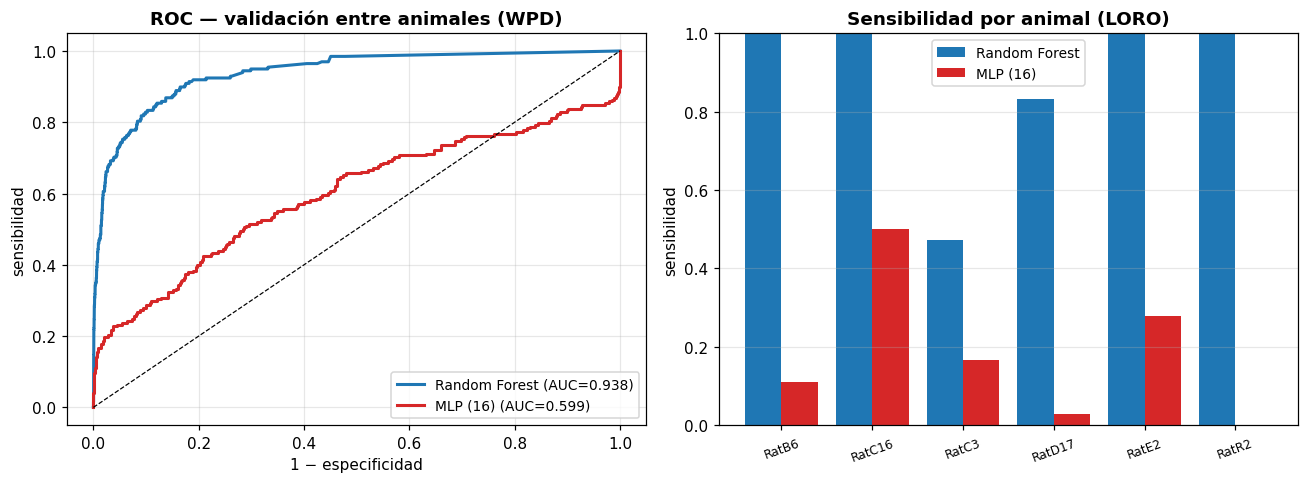

In [ ]:
# ══ MLP CHICO — ajustado al tamaño del dataset ═══════════════════════════
# Única diferencia con el anterior: red mucho más chica.
# (16,) en vez de (64,32) → ~1200 pesos en vez de ~7000, para 198 ictales.
# Y más regularización (alpha 1e-2). Todo lo demás idéntico → comparable.

def modelo_mlp_chico():
    return Pipeline([('sc', StandardScaler()),
                     ('nn', MLPClassifier(hidden_layer_sizes=(16,),
                          activation='relu', solver='adam',
                          alpha=1e-2,                    # más regularización
                          learning_rate_init=1e-3,
                          max_iter=600, early_stopping=True,
                          n_iter_no_change=20, random_state=0))])

print('='*60); print('MODELO 2b · MLP CHICO (WPD)'); print('='*60)
RES_MLP = evaluar_loro(modelo_mlp_chico, XN, y, grupo, 'MLP (16)')

# ── comparación (RF ya está en memoria, no se recalcula) ────────────────
print('\n'+'='*45)
print(f'{"modelo":<18s}{"sens":>9s}{"espec":>9s}{"AUC":>9s}')
print('-'*45)
for R in (RES_RF, RES_MLP):
    print(f'{R["nombre"]:<18s}{R["sens"]:>9.3f}{R["espec"]:>9.3f}{R["auc"]:>9.3f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for R, col in ((RES_RF,'tab:blue'), (RES_MLP,'tab:red')):
    m = np.isfinite(R['prob'])
    fpr, tpr, _ = roc_curve(y[m], R['prob'][m])
    ax[0].plot(fpr, tpr, color=col, lw=2,
               label=f'{R["nombre"]} (AUC={roc_auc_score(y[m],R["prob"][m]):.3f})')
ax[0].plot([0,1],[0,1],'k--',lw=.8)
ax[0].set_xlabel('1 − especificidad'); ax[0].set_ylabel('sensibilidad')
ax[0].set_title('ROC — validación entre animales (WPD)', fontweight='bold')
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)

x_ = np.arange(len(ratas))
s_rf = [next(f['sens'] for f in RES_RF['filas'] if f['rata']==r) for r in ratas]
s_nn = [next(f['sens'] for f in RES_MLP['filas'] if f['rata']==r) for r in ratas]
ax[1].bar(x_-.2, s_rf, .4, label='Random Forest', color='tab:blue')
ax[1].bar(x_+.2, s_nn, .4, label=RES_MLP['nombre'], color='tab:red')
ax[1].set_xticks(x_); ax[1].set_xticklabels(ratas, rotation=20, fontsize=8)
ax[1].set_ylabel('sensibilidad'); ax[1].set_ylim(0,1)
ax[1].set_title('Sensibilidad por animal (LORO)', fontweight='bold')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3, axis='y')
plt.tight_layout(); plt.show()

"Se ajustó el tamaño de la red al volumen de datos: la arquitectura grande (64,32) dio AUC 0.517 (azar) por sobreajuste; reducirla a (16,) la mejoró a 0.576, confirmando el diagnóstico, pero sigue lejos del Random Forest (0.960). Con 198 ventanas ictales, una red neuronal no dispone de suficientes ejemplos positivos, mientras que el Random Forest es robusto en pocos datos."